# Phase 2: Factually Grounded RAG

## Exercise

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import json

from transformers import AutoTokenizer, AutoModel
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances

In [2]:
# Get results from phase 1
with open("outputs/phase1_outputs/retrieved_docs_knn.json", "r", encoding="utf-8") as f:
    phase1_results = json.load(f)

In [3]:
MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(
    MODEL_NAME,
    output_hidden_states=True,
    output_attentions=True
)

model.eval()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

### Positional Embeddings

In [4]:
word = "medicine"
text = " ".join([word] * 200)

inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    max_length=202  # CLS + 200 tokens + SEP
)

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
print(tokens[:10], "...", tokens[-10:])

['[CLS]', 'medicine', 'medicine', 'medicine', 'medicine', 'medicine', 'medicine', 'medicine', 'medicine', 'medicine'] ... ['medicine', 'medicine', 'medicine', 'medicine', 'medicine', 'medicine', 'medicine', 'medicine', 'medicine', '[SEP]']


In [5]:
with torch.no_grad():
    position_embeddings = model.embeddings.position_embeddings.weight

# positions for the real token sequence
seq_len = inputs["input_ids"].shape[1]
pos_embs = position_embeddings[:seq_len].detach().cpu().numpy()

# remove CLS and SEP
token_pos_embs = pos_embs[1:-1]
token_labels = tokens[1:-1]

print(token_pos_embs.shape)

(200, 768)


#### 2a.Distance to first token

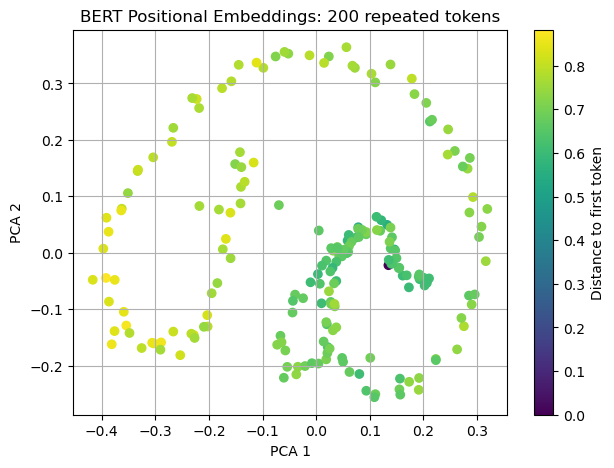

In [6]:
dist_to_first = np.linalg.norm(token_pos_embs - token_pos_embs[0], axis=1)

pca = PCA(n_components=2)
pos_2d = pca.fit_transform(token_pos_embs)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    pos_2d[:, 0],
    pos_2d[:, 1],
    c=dist_to_first
)
plt.colorbar(scatter, label="Distance to first token")
plt.title("BERT Positional Embeddings: 200 repeated tokens")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()

#### 2b. Distance matrix

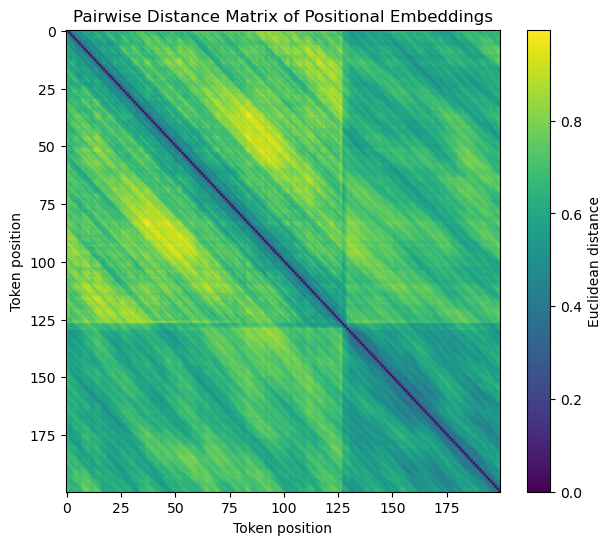

In [7]:
dist_matrix = pairwise_distances(token_pos_embs, metric="euclidean")

plt.figure(figsize=(7, 6))
plt.imshow(dist_matrix, aspect="auto")
plt.colorbar(label="Euclidean distance")
plt.title("Pairwise Distance Matrix of Positional Embeddings")
plt.xlabel("Token position")
plt.ylabel("Token position")
plt.show()

### Contextual embeddings from layer 0 to 11

In [8]:
text = "Sleep apnea can be improved by weight loss, avoiding alcohol, and positional therapy."

inputs = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

hidden_states = outputs.hidden_states
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

print("Number of layers:", len(hidden_states))
print(tokens)

Number of layers: 13
['[CLS]', 'sleep', 'ap', '##nea', 'can', 'be', 'improved', 'by', 'weight', 'loss', ',', 'avoiding', 'alcohol', ',', 'and', 'position', '##al', 'therapy', '.', '[SEP]']


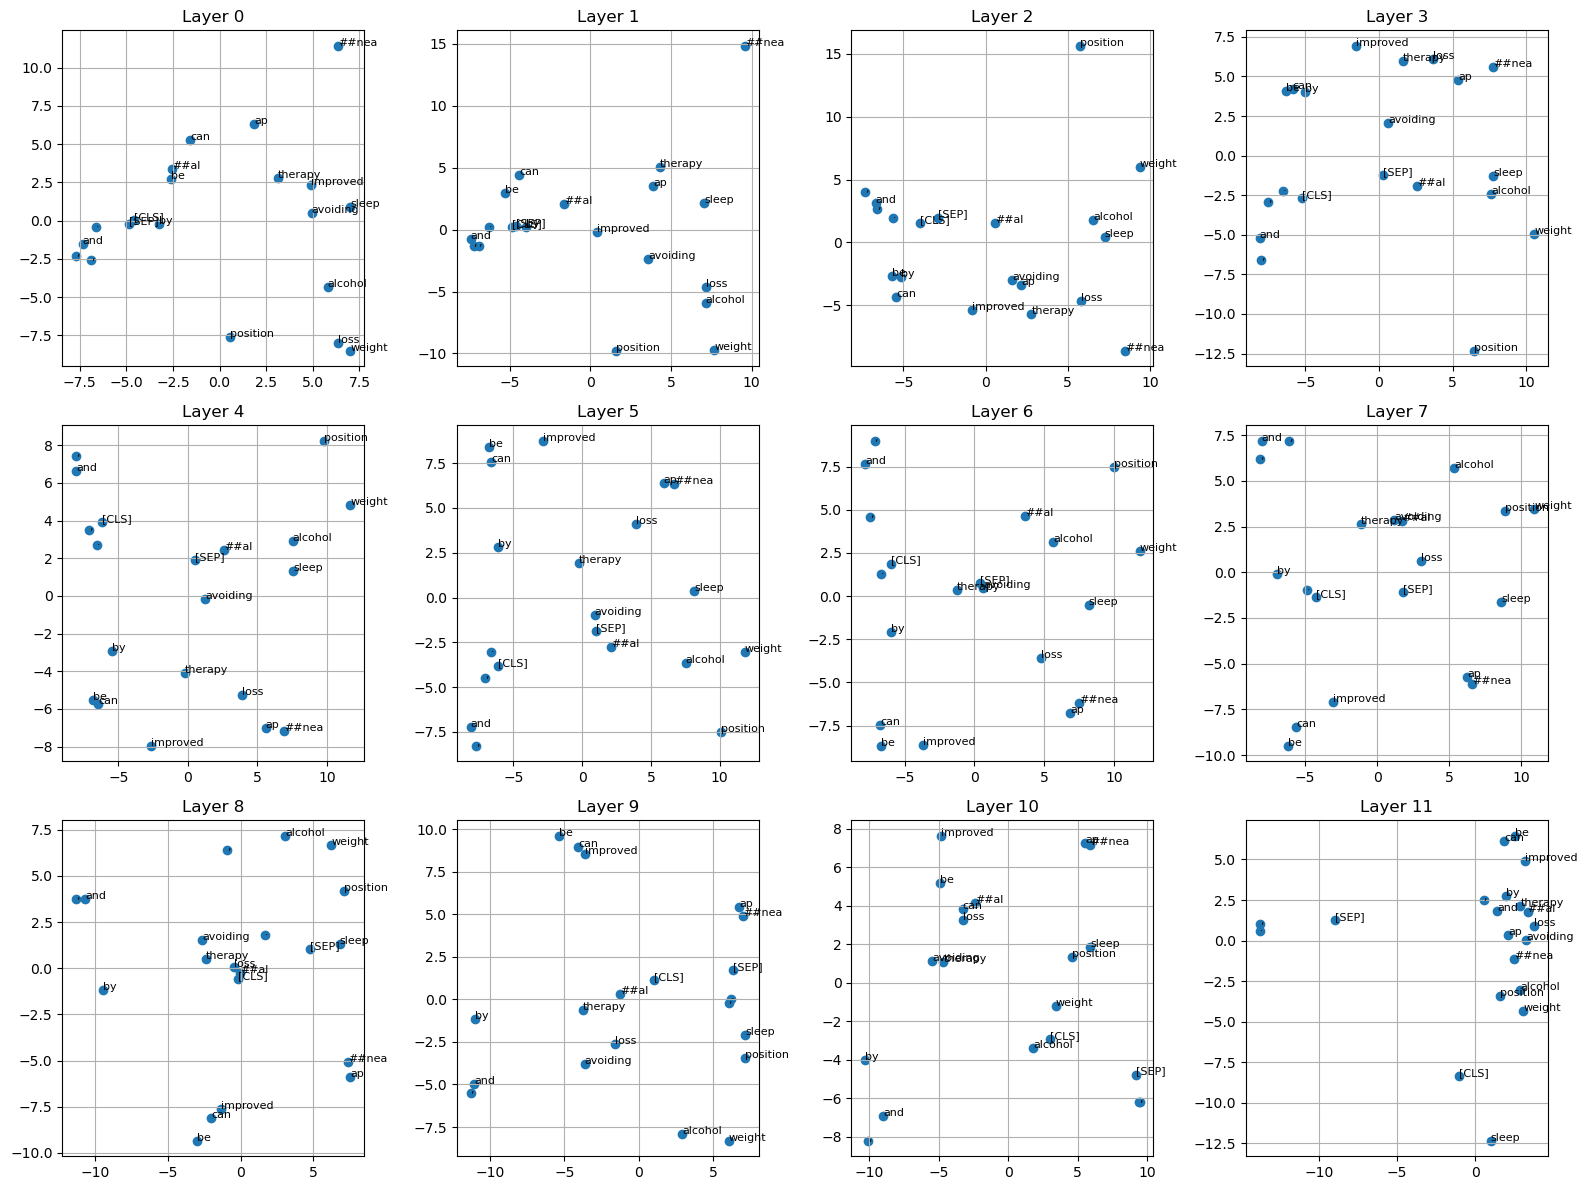

In [9]:
layers = hidden_states[1:]  # 12 BERT layers

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for layer_idx, layer_tensor in enumerate(layers):
    emb = layer_tensor[0].detach().cpu().numpy()

    pca = PCA(n_components=2)
    emb_2d = pca.fit_transform(emb)

    ax = axes[layer_idx]
    ax.scatter(emb_2d[:, 0], emb_2d[:, 1])

    for i, token in enumerate(tokens):
        ax.annotate(token, (emb_2d[i, 0], emb_2d[i, 1]), fontsize=8)

    ax.set_title(f"Layer {layer_idx}")
    ax.grid(True)

plt.tight_layout()
plt.show()

### Self-attention Visualization

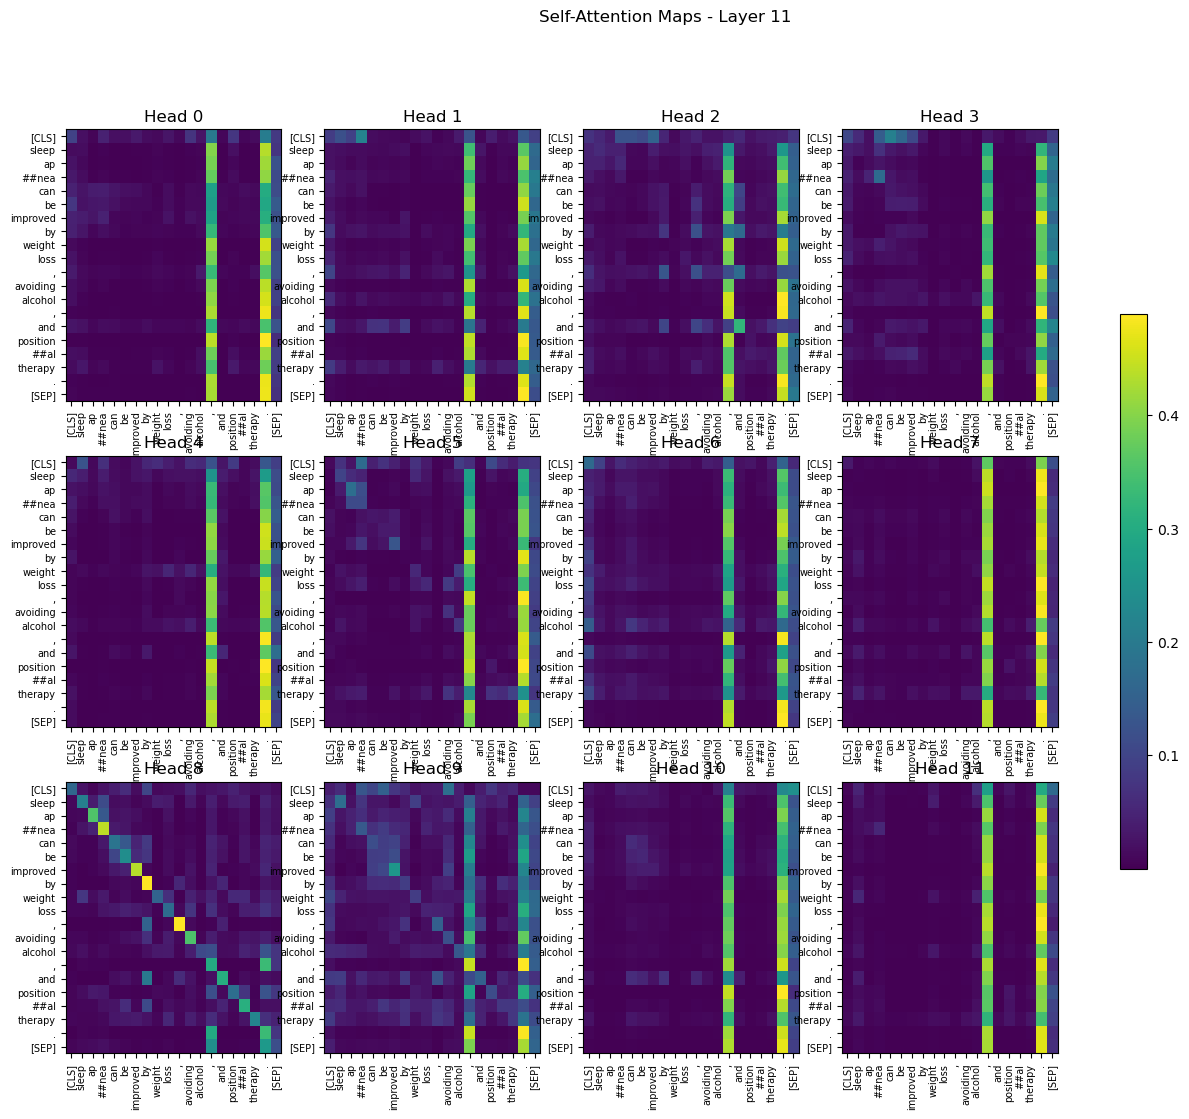

In [10]:
with torch.no_grad():
    outputs = model(**inputs)

attentions = outputs.attentions

layer_idx = 11
attention_layer = attentions[layer_idx][0].detach().cpu().numpy()

num_heads = attention_layer.shape[0]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for head in range(num_heads):
    ax = axes[head]
    im = ax.imshow(attention_layer[head], aspect="auto")

    ax.set_title(f"Head {head}")
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=90, fontsize=7)
    ax.set_yticklabels(tokens, fontsize=7)

fig.colorbar(im, ax=axes.tolist(), shrink=0.6)
plt.suptitle(f"Self-Attention Maps - Layer {layer_idx}")
plt.show()

## Answer Generation

In [11]:
import re

def split_sentences(text):
    text = text.strip()
    if not text:
        return []
    sentences = re.split(r'(?<=[.!?])\s+', text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

In [12]:
# Get top retrieved documents for one query
def get_top_docs_for_query(qid, run_results, doc_by_pmid, top_k=10):
    pmids = [pmid for pmid, score in run_results[qid][:top_k]]
    return [doc_by_pmid[pmid] for pmid in pmids if pmid in doc_by_pmid]

In [ ]:
from sentence_transformers import CrossEncoder

# MedCPT Cross-Encoder: trained on PubMed query-article pairs
cross_encoder = CrossEncoder("ncbi/MedCPT-Cross-Encoder", max_length=512)


config.json:   0%|          | 0.00/741 [00:00<?, ?B/s]

c:\Users\kaime\anaconda3\envs\nlp-cv-ir\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\kaime\.cache\huggingface\hub\models--ncbi--MedCPT-Cross-Encoder. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

In [ ]:
import torch
from transformers import pipeline

# Flan-T5-Large: instruction-following encoder-decoder for structured answer generation
_decoder_pipeline = pipeline(
    "text2text-generation",
    model="google/flan-t5-large",
    device=0 if torch.cuda.is_available() else -1,
)

def generate_answer_local(prompt, max_new_tokens=400):
    result = _decoder_pipeline(prompt, max_new_tokens=max_new_tokens, do_sample=False)
    return result[0]["generated_text"].strip()

print("Decoder loaded:", _decoder_pipeline.model.config._name_or_path)


: 

In [ ]:
def select_reference_sentences(query_text, retrieved_docs, cross_encoder, top_sentences_per_doc=3):
    selected = []

    for doc in retrieved_docs:
        pmid = doc["pmid"]
        abstract = doc["abstract"]

        sentences = split_sentences(abstract)
        if not sentences:
            continue

        pairs = [(query_text, sent) for sent in sentences]
        scores = cross_encoder.predict(pairs)

        ranked = sorted(
            zip(sentences, scores),
            key=lambda x: x[1],
            reverse=True
        )

        for sent, score in ranked[:top_sentences_per_doc]:
            selected.append({
                "pmid": pmid,
                "sentence": sent,
                "score": float(score)
            })

    return selected

: 

### Build RAG context

In [ ]:
def build_context(reference_sentences, max_sentences=20):
    reference_sentences = sorted(
        reference_sentences,
        key=lambda x: x["score"],
        reverse=True
    )[:max_sentences]

    context_lines = []
    for i, ref in enumerate(reference_sentences, start=1):
        context_lines.append(
            f'[{i}] PMID {ref["pmid"]}: {ref["sentence"]}'
        )

    return "\n".join(context_lines)

: 

### Answer Prompt

In [ ]:
def build_answer_prompt(question, context):
    return f"""
You are a biomedical question answering assistant.

Answer the question using ONLY the reference sentences provided below.

Rules:
- The answer must be no more than 250 words.
- Every answer sentence must include PMID citations in square brackets.
- Use this exact citation format: [PMID: 12345678].
- Use no more than 3 PMIDs per answer sentence.
- Only cite PMIDs that appear in the reference sentences.
- Each cited PMID must directly support the sentence where it is cited.
- Do not invent facts.
- Do not use outside knowledge.
- If the references do not contain enough evidence, say so and cite the closest supporting PMID.

Question:
{question}

Reference sentences:
{context}

Write the final answer only:
"""

: 

In [ ]:
def generate_answer(question, context, llm_client):
    prompt = build_answer_prompt(question, context)
    response = llm_client(prompt)
    return response.strip()

: 

In [ ]:
import os
import json
import uuid
import requests
import time
import ast
from dotenv import load_dotenv

API_ENDPOINT = "https://api.iaedu.pt/agent-chat//api/v1/agent/cmamvd3n40000c801qeacoad2/stream"

load_dotenv()

API_KEY = os.getenv("IAEDU_API_KEY")
# os.environ["IAEDU_API_KEY"] = "sk-usr-3owbf63h2qkoixn8rtorz5d0all1ax95v2y"

if API_KEY is None:
    raise ValueError("Missing IAEDU_API_KEY environment variable.")

def _is_uuid(text):
    try:
        uuid.UUID(text.strip())
        return True
    except (ValueError, AttributeError):
        return False
    
# def parse_iaedu_response(text):
#     import ast
#     import json

#     final_contents = []
#     stream_chunks = []

#     for raw_line in text.splitlines():
#         line = raw_line.strip()

#         if not line:
#             continue

#         if line.startswith("data:"):
#             line = line[len("data:"):].strip()

#         if line in {"[DONE]", "DONE", "Processing"}:
#             continue

#         if _is_uuid(line):
#             continue

#         obj = None
#         try:
#             obj = json.loads(line)
#         except Exception:
#             try:
#                 obj = ast.literal_eval(line)
#             except Exception:
#                 obj = None

#         if isinstance(obj, dict):
#             content = obj.get("content")

#             if content is None and isinstance(obj.get("message"), dict):
#                 content = obj["message"].get("content")

#             if content:
#                 content = str(content).strip()

#                 if "Rate limit reached" in content or "429" in content:
#                     raise RuntimeError("IAedu rate limit reached.")

#                 if not _is_uuid(content) and content.lower() != "processing":
#                     final_contents.append(content)

#             continue

#         if "Rate limit reached" in line or "429" in line:
#             raise RuntimeError("IAedu rate limit reached.")

#         stream_chunks.append(line)

#     if final_contents:
#         return final_contents[-1].strip()

#     return "".join(stream_chunks).strip()

def extract_content_if_dict_string(text):
    text = text.strip()

    try:
        obj = ast.literal_eval(text)
        if isinstance(obj, dict) and "content" in obj:
            return obj["content"].strip()
    except Exception:
        pass

    return text

# def call_llm(prompt, thread_id=None, max_retries=5):
#     if thread_id is None:
#         thread_id = str(uuid.uuid4())

#     form_data = {
#         "channel_id": "cmoh3pa5o286kj301ga04tio8",
#         "thread_id": thread_id,
#         "user_info": "{}",
#         "message": prompt
#     }

#     headers = {
#         "x-api-key": API_KEY
#     }

#     for attempt in range(max_retries):
#         response = requests.post(
#             API_ENDPOINT,
#             data=form_data,
#             headers=headers,
#             timeout=120,
#             stream=True
#         )

#         response.raise_for_status()

#         raw_lines = []
#         for line in response.iter_lines(decode_unicode=True):
#             if line:
#                 raw_lines.append(line)

#         raw_text = "\n".join(raw_lines)

#         try:
#             parsed = parse_iaedu_response(raw_text)

#             if not parsed or _is_uuid(parsed):
#                 raise RuntimeError(
#                     "IAedu response did not contain assistant content.\n"
#                     f"Raw response:\n{raw_text}"
#                 )

#             return extract_content_if_dict_string(parsed)

#         except RuntimeError as e:
#             if "rate limit" in str(e).lower():
#                 wait = 20 * (attempt + 1)
#                 print(f"Rate limit reached. Waiting {wait}s...")
#                 # time.sleep(wait)
#                 continue
#             raise

#     raise RuntimeError("Failed after repeated IAedu rate limits.")

def parse_iaedu_response(text):
    """
    Extract the final assistant content from the IAedu stream.

    The endpoint mixes status lines, token chunks, a final AI-message repr,
    and a run id. Prefer the final message content when present; otherwise
    fall back to joining streamed token chunks without inserting newlines.
    """
    import ast

    final_contents = []
    stream_chunks = []

    for raw_line in text.splitlines():
        line = raw_line

        if line.startswith("data:"):
            line = line[len("data:"):].lstrip()

        if not line.strip():
            continue

        stripped = line.strip()
        if stripped in {"[DONE]", "DONE", "Processing"}:
            continue

        if _is_uuid(stripped):
            continue

        obj = None
        try:
            obj = json.loads(stripped)
        except Exception:
            try:
                obj = ast.literal_eval(stripped)
            except Exception:
                obj = None

        if isinstance(obj, dict):
            content = obj.get("content")
            if content is None and isinstance(obj.get("message"), dict):
                content = obj["message"].get("content")
            if content is not None and not _is_uuid(str(content)):
                final_contents.append(str(content))
            continue

        stream_chunks.append(line)

    if final_contents:
        return final_contents[-1].strip()

    return "".join(stream_chunks).strip()


def call_llm(prompt, thread_id="phase2-thread"):
    form_data = {
        "channel_id": "cmoh3pa5o286kj301ga04tio8",
        "thread_id": thread_id,
        "user_info": "{}",
        "message": prompt
    }

    headers = {
        "x-api-key": API_KEY
    }

    response = requests.post(
        API_ENDPOINT,
        data=form_data,
        headers=headers,
        timeout=120,
        stream=True
    )

    response.raise_for_status()

    raw_lines = []
    for line in response.iter_lines(decode_unicode=True):
        if line is not None:
            raw_lines.append(line)

    raw_text = "\n".join(raw_lines)
    parsed = parse_iaedu_response(raw_text)

    if not parsed or _is_uuid(parsed):
        raise RuntimeError(
            "IAedu response did not contain assistant content. "
            "It only contained a run id/status. Raw response was:\n"
            f"{raw_text}"
        )

    return extract_content_if_dict_string(parsed)

: 

In [ ]:
print(call_llm("Reply only with: OK"))

OK


: 

### Store Outputs

In [ ]:
phase2_outputs = {}

for qid, item in tqdm(phase1_results.items(), desc="Generating answers"):
    query_text = item["query"]
    retrieved_docs = item["results"][:10]

    # Step 1: select top-3 reference sentences per doc with MedCPT cross-encoder
    refs = select_reference_sentences(
        query_text,
        retrieved_docs,
        cross_encoder,
        top_sentences_per_doc=3
    )

    # Step 2: build RAG context from selected sentences
    context = build_context(refs, max_sentences=20)

    # Step 3: generate answer with local decoder (flan-t5-large)
    answer = generate_answer(query_text, context, generate_answer_local)

    phase2_outputs[qid] = {
        "question": query_text,
        "retrieved_pmids": [doc["pmid"] for doc in retrieved_docs],
        "reference_sentences": refs,
        "context": context,
        "answer": answer
    }


: 

### Answer Validation

In [ ]:
import re

def count_words(text):
    return len(text.split())

def extract_pmids(text):
    return set(re.findall(r'\b\d{5,}\b', text))

def validate_answer(answer, valid_pmids):
    used_pmids = extract_pmids(answer)
    valid_pmids = set(valid_pmids)

    return {
        "word_count": count_words(answer),
        "under_250_words": count_words(answer) <= 250,
        "used_pmids": sorted(used_pmids),
        "invalid_pmids": sorted(used_pmids - valid_pmids),
        "all_pmids_valid": len(used_pmids - valid_pmids) == 0
    }

for qid, output in phase2_outputs.items():
    valid_pmids = {ref["pmid"] for ref in output["reference_sentences"]}
    output["validation"] = validate_answer(output["answer"], valid_pmids)

: 

### Official judge prompt

In [ ]:
def build_sentence_alignment_prompt(question, answer_sentence):
    return f"""
You are an expert annotator. Given a question and an answer sentence, your task is to assign
a single label from the following list: ['Required', 'Unnecessary', 'Borderline', 'Inappropriate'].

The label definition are as follows:

Required: The answer sentence is necessary to have in the generated answer for completeness of the answers.

Unnecessary: The answer sentence is not required to have included in the generated answer.
An answer sentence may be unnecessary for several reasons:
(a) If including it would cause information overload if it is added to the answer;
(b) If it is trivial, e.g., stating that many treatment options exist.
(c) If it consists entirely of a recommendation to see a health professional.
(d) If it is not relevant to the answer.

Borderline: If an answer sentence is relevant, possibly even “good to know,” but not required,
the answer sentence may be marked borderline.

Inappropriate: The assertion may harm the patient.

Question:
{question}

Answer sentence:
{answer_sentence}

Do not generate anything else.
Respond ONLY with the label no explanation.
"""

: 

In [ ]:
def build_answer_entailment_prompt(question, complete_answer, reference_sentences):
    return f"""
You are an expert annotator. Given a question and a complete answer and its reference
sentences, your task is to assign a single label from the following list:
['Unsupported', 'Partially Supported', 'Supported'].

The label definition are as follows:

Supported: The answer is completely supported by the reference sentences.

Partially Supported: The answer is relevant and partially supported by the reference sentences.

Unsupported: The answer is not supported by the provided sentences and may harm the patient.

Question:
{question}

Complete answer:
{complete_answer}

Reference sentences:
{reference_sentences}

Do not generate anything else.
Respond ONLY with the label no explanation.
"""

: 

### Label Cleaning

In [ ]:
def clean_sentence_label(text):
    text = text.strip().lower()

    if "inappropriate" in text:
        return "Inappropriate"
    if "unnecessary" in text:
        return "Unnecessary"
    if "borderline" in text:
        return "Borderline"
    if "required" in text:
        return "Required"

    return "UNKNOWN"


def clean_entailment_label(text):
    text = text.strip().lower()

    if "partially" in text:
        return "Partially Supported"
    if "unsupported" in text or "unsuported" in text:
        return "Unsupported"
    if "supported" in text:
        return "Supported"

    return "UNKNOWN"

: 

### Judge Functions

In [ ]:
def judge_sentence_alignment(question, answer_sentence):
    prompt = build_sentence_alignment_prompt(question, answer_sentence)
    raw = call_llm(prompt)
    return clean_sentence_label(raw), raw


def judge_answer_entailment(question, answer, context):
    prompt = build_answer_entailment_prompt(question, answer, context)
    raw = call_llm(prompt)
    return clean_entailment_label(raw), raw

: 

### LLM Judge Evaluation

In [ ]:
def split_answer_sentences(answer):
    sentences = re.split(r'(?<=[.!?])\s+', answer.strip())
    return [s.strip() for s in sentences if s.strip()]

for qid, output in tqdm(phase2_outputs.items(), desc="LLM Judge"):
    question = output["question"]
    answer = output["answer"]
    context = output["context"]

    answer_sentences = split_answer_sentences(answer)

    sentence_alignment = []

    for sent in answer_sentences:
        label, raw = judge_sentence_alignment(question, sent)

        sentence_alignment.append({
            "sentence": sent,
            "label": label,
            "raw_output": raw
        })

        time.sleep(1)

    entailment_label, entailment_raw = judge_answer_entailment(
        question,
        answer,
        context
    )

    output["sentence_alignment"] = sentence_alignment
    output["answer_entailment"] = {
        "label": entailment_label,
        "raw_output": entailment_raw
    }

    time.sleep(1)

LLM Judge: 100%|██████████| 2/2 [01:55<00:00, 57.92s/it]


: 

### Summary Table

In [ ]:
from collections import Counter
import pandas as pd

sentence_counts = Counter()
entailment_counts = Counter()

for qid, output in phase2_outputs.items():
    for item in output.get("sentence_alignment", []):
        sentence_counts[item["label"]] += 1

    entailment = output.get("answer_entailment", {}).get("label")
    if entailment:
        entailment_counts[entailment] += 1

df_sentence_alignment = pd.DataFrame(
    sentence_counts.items(),
    columns=["Label", "Count"]
).sort_values("Label")

df_entailment = pd.DataFrame(
    entailment_counts.items(),
    columns=["Label", "Count"]
).sort_values("Label")

display(df_sentence_alignment)
display(df_entailment)

,Label,Count
2,Borderline,1
0,Required,5
1,UNKNOWN,2


,Label,Count
0,UNKNOWN,2


: 

### Save Outputs

In [ ]:
from pathlib import Path

Path("outputs/phase2").mkdir(parents=True, exist_ok=True)

with open("outputs/phase2/phase2_outputs.json", "w", encoding="utf-8") as f:
    json.dump(phase2_outputs, f, indent=2, ensure_ascii=False)

df_sentence_alignment.to_csv("outputs/phase2/sentence_alignment_summary.csv", index=False)
df_entailment.to_csv("outputs/phase2/answer_entailment_summary.csv", index=False)

: 

### Inspection

In [ ]:
for qid, output in phase2_outputs.items():
    print("=" * 100)
    print("QID:", qid)
    print("QUESTION:")
    print(output["question"])

    print("\nANSWER:")
    print(output["answer"])

    print("\nVALIDATION:")
    print(output["validation"])

    print("\nSENTENCE ALIGNMENT:")
    for s in output.get("sentence_alignment", []):
        print("-", s["label"], ":", s["sentence"])

    print("\nANSWER ENTAILMENT:")
    print(output.get("answer_entailment", {}).get("label"))

QID: 116
QUESTION:
natural treatments for sleep apnea Are there ways to prevent sleep apnea or treat it naturally? The patient is looking for natural remedies to prevent and treat sleep apnea.

ANSWER:
Natural approaches to prevent and manage obstructive sleep apnea (OSA) include weight loss, avoiding central nervous system depressants, treating nasal congestion, and sleeping in the lateral position [PMID: 18651518, PMID: 21603432]. Conservative measures such as alcohol and tobacco cessation are also strongly encouraged [PMID: 21603432]. 

Complementary and integrative approaches, when combined with conventional methods, may offer some reduction in the apnea-hypopnea index, but their effectiveness as standalone treatments is not well established [PMID: 37532368, PMID: 36088151]. Nonprescription therapies, such as nasal dilators, oral lubricants, dietary supplements, and magnetic pillows, are available but lack sufficient evidence to support their utility in treating OSA [PMID: 15162258

: 